# CSI Based WiFi Sensing Analysis


### By Seth Kantz and Matthew Delafield

Graphs to support further analysis


### Imports


In [68]:
from pathlib import Path
import numpy as np
import re
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

import math
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

###

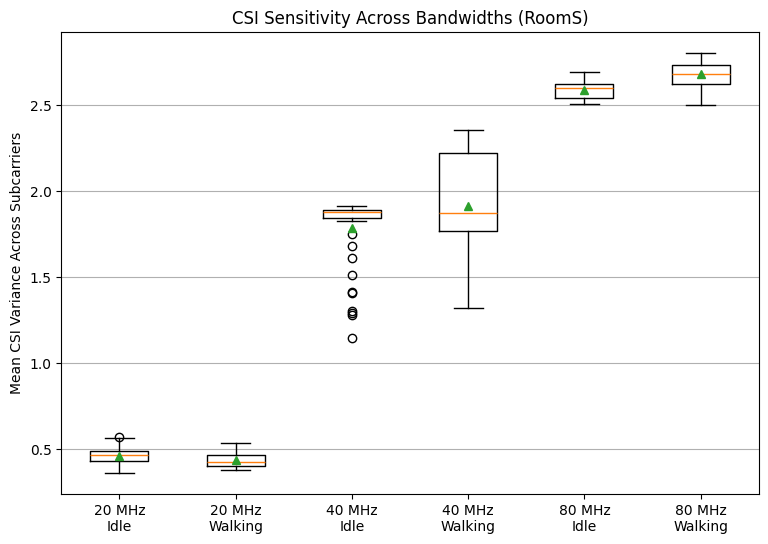

Condition,Motion,Static,Delta (Motion-Static)
Bandwidth,,,
20 MHz,0.440034,0.461607,-0.021573
40 MHz,1.915415,1.783172,0.132243
80 MHz,2.676836,2.588158,0.088679


In [96]:
# Boxplot: CSI Sensitivity by Bandwidth (Seth data)

plt.figure(figsize=(9, 6))

labels = []
data = []

for bw in ["20 MHz", "40 MHz", "80 MHz"]:
    for condition in ["Idle", "Walking"]:
        vals = sensitivity_df[
            (sensitivity_df["Bandwidth"] == bw) &
            (sensitivity_df["Condition"] == condition)
        ]["CSI Variance"].values

        data.append(vals)
        labels.append(f"{bw}\n{condition}")

plt.boxplot(data, tick_labels=labels, showmeans=True)

plt.ylabel("Mean CSI Variance Across Subcarriers")
plt.title("CSI Sensitivity Across Bandwidths (RoomS)")
plt.grid(True, axis="y")
plt.xticks(rotation=0)
plt.show()

# Compute mean per bandwidth + condition
seth_summary = (
    sensitivity_df
    .groupby(["Bandwidth", "Condition"])["CSI Variance"]
    .mean()
    .unstack()
)

# Rename columns for clarity
seth_summary = seth_summary.rename(columns={
    "Idle": "Static",
    "Walking": "Motion"
})

# Compute delta
seth_summary["Delta (Motion-Static)"] = (
    seth_summary["Motion"] - seth_summary["Static"]
)

# Optional: reorder columns nicely
seth_summary = seth_summary[["Motion", "Static", "Delta (Motion-Static)"]]

display(seth_summary)

In [74]:
ROOT = Path("data/hf_dataset/pcap_csvs/split_csv")

print(list((ROOT / "20_idle_ch11").glob("*.csv"))[:3])
print(list((ROOT / "40_idle").glob("*.csv"))[:3])
print(list((ROOT / "80_idle").glob("*.csv"))[:3])

[WindowsPath('wifi_csi_seth/20_idle_ch11/20_ch11_idle_1122_split_02.csv'), WindowsPath('wifi_csi_seth/20_idle_ch11/20_ch11_idle_1122_split_03.csv'), WindowsPath('wifi_csi_seth/20_idle_ch11/20_ch11_idle_1122_split_04.csv')]
[WindowsPath('wifi_csi_seth/40_idle/40_idle_0518_split_02.csv'), WindowsPath('wifi_csi_seth/40_idle/40_idle_0518_split_03.csv'), WindowsPath('wifi_csi_seth/40_idle/40_idle_0518_split_04.csv')]
[WindowsPath('wifi_csi_seth/80_idle/80_idle_0546_split_02.csv'), WindowsPath('wifi_csi_seth/80_idle/80_idle_0546_split_03.csv'), WindowsPath('wifi_csi_seth/80_idle/80_idle_0546_split_04.csv')]


In [86]:
ROOT_MATT = Path("data/hf_dataset/pcap_csvs/split_csv")

matt_pairs = {
    # 5 ft
    "20 MHz - 5 ft": ("20_5ft_static", "20_5ft_motion", SUBCARRIERS_20MHz),
    "40 MHz - 5 ft": ("40_5ft_static", "40_5ft_motion", SUBCARRIERS_40MHz),
    "80 MHz - 5 ft": ("80_5ft_static", "80_5ft_motion", SUBCARRIERS_80MHz),

    # 10 ft
    "20 MHz - 10 ft": ("20_10ft_static", "20_10ft_motion", SUBCARRIERS_20MHz),
    "40 MHz - 10 ft": ("40_10ft_static", "40_10ft_motion", SUBCARRIERS_40MHz),
    "80 MHz - 10 ft": ("80_10ft_static", "80_10ft_motion", SUBCARRIERS_80MHz),
}

matt_rows = []

for scenario_label, (static_folder, motion_folder, subcarriers) in matt_pairs.items():

    static_path = ROOT_MATT / static_folder
    motion_path = ROOT_MATT / motion_folder

    print("\n", scenario_label)
    print("Static files:", len(list(static_path.glob("*.csv"))))
    print("Motion files:", len(list(motion_path.glob("*.csv"))))

    for file in sorted(static_path.glob("*.csv")):
        v = file_csi_variance(file, subcarriers)
        if v is not None:
            matt_rows.append({
                "Scenario": scenario_label,
                "Condition": "Static",
                "CSI Variance": v
            })

    for file in sorted(motion_path.glob("*.csv")):
        v = file_csi_variance(file, subcarriers)
        if v is not None:
            matt_rows.append({
                "Scenario": scenario_label,
                "Condition": "Motion",
                "CSI Variance": v
            })

matt_sensitivity_df = pd.DataFrame(matt_rows)

display(matt_sensitivity_df.head())
print("Total rows:", len(matt_sensitivity_df))


 20 MHz - 5 ft
Static files: 5
Motion files: 4

 40 MHz - 5 ft
Static files: 386
Motion files: 390

 80 MHz - 5 ft
Static files: 248
Motion files: 327

 20 MHz - 10 ft
Static files: 6
Motion files: 8

 40 MHz - 10 ft
Static files: 403
Motion files: 355

 80 MHz - 10 ft
Static files: 329
Motion files: 325


,Scenario,Condition,CSI Variance
0,20 MHz - 5 ft,Static,0.180334
1,20 MHz - 5 ft,Static,0.161132
2,20 MHz - 5 ft,Static,0.153971
3,20 MHz - 5 ft,Static,0.155985
4,20 MHz - 5 ft,Static,0.171194


Total rows: 2786


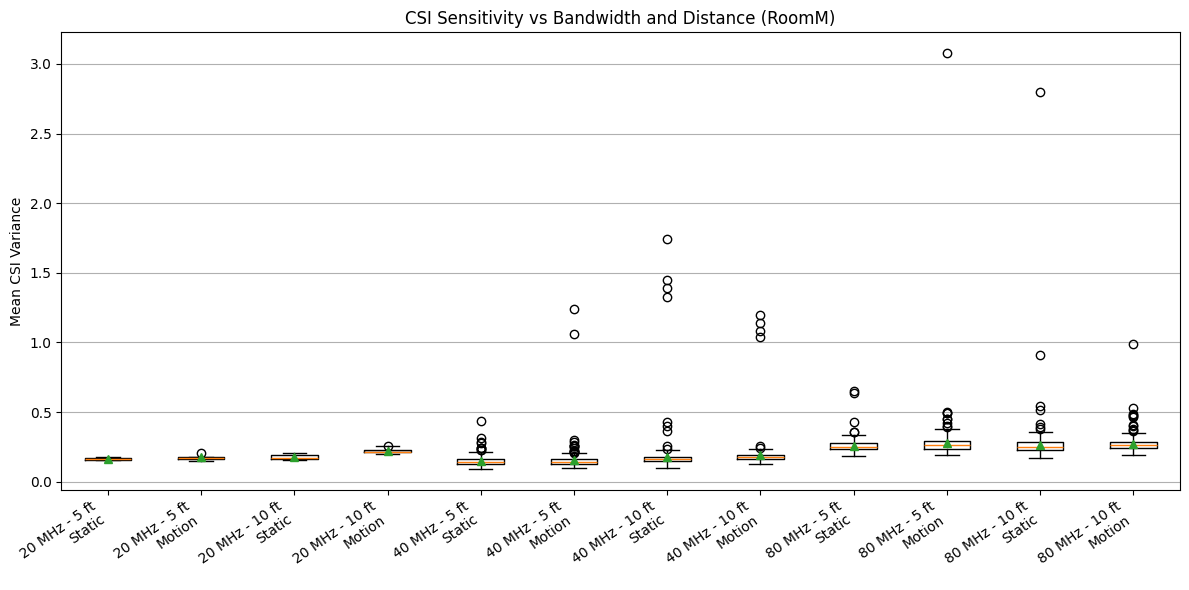

Condition,Motion,Static,Delta (Motion-Static)
Scenario,,,
20 MHz - 10 ft,0.223501,0.176106,0.047395
20 MHz - 5 ft,0.174400,0.164523,0.009877
40 MHz - 10 ft,0.188751,0.176663,0.012088
40 MHz - 5 ft,0.152700,0.148289,0.004411
80 MHz - 10 ft,0.270021,0.265857,0.004164
80 MHz - 5 ft,0.280929,0.259530,0.021398


In [92]:
plt.figure(figsize=(12, 6))

labels = []
data = []

scenario_order = [
    "20 MHz - 5 ft", "20 MHz - 10 ft",
    "40 MHz - 5 ft", "40 MHz - 10 ft",
    "80 MHz - 5 ft", "80 MHz - 10 ft",
]

for scenario in scenario_order:
    for condition in ["Static", "Motion"]:
        vals = matt_sensitivity_df[
            (matt_sensitivity_df["Scenario"] == scenario) &
            (matt_sensitivity_df["Condition"] == condition)
        ]["CSI Variance"].values

        data.append(vals)
        labels.append(f"{scenario}\n{condition}")

plt.boxplot(data, tick_labels=labels, showmeans=True)

plt.ylabel("Mean CSI Variance")
plt.title("CSI Sensitivity vs Bandwidth and Distance (RoomM)")
plt.grid(True, axis="y")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

summary = (
    matt_sensitivity_df
    .groupby(["Scenario", "Condition"])["CSI Variance"]
    .mean()
    .unstack()
)
summary["Delta (Motion-Static)"] = summary["Motion"] - summary["Static"]
display(summary)

In [88]:
print(matt_sensitivity_df.groupby(["Scenario", "Condition"])["CSI Variance"].mean())

Scenario        Condition
20 MHz - 10 ft  Motion       0.223501
                Static       0.176106
20 MHz - 5 ft   Motion       0.174400
                Static       0.164523
40 MHz - 10 ft  Motion       0.188751
                Static       0.176663
40 MHz - 5 ft   Motion       0.152700
                Static       0.148289
80 MHz - 10 ft  Motion       0.270021
                Static       0.265857
80 MHz - 5 ft   Motion       0.280929
                Static       0.259530
Name: CSI Variance, dtype: float32


In [94]:
ROOT_SETH = Path("data/hf_dataset/pcap_csvs/split_csv")

blocked_pairs = {
    "40 MHz (Unblocked)": ("40_idle", "40_walking", SUBCARRIERS_40MHz),
    "40 MHz (Blocked)": ("40_idle_blocked", "40_walking_blocked", SUBCARRIERS_40MHz),

    "80 MHz (Unblocked)": ("80_idle", "80_walking", SUBCARRIERS_80MHz),
    "80 MHz (Blocked)": ("80_idle_blocked", "80_walking_blocked", SUBCARRIERS_80MHz),
}

blocked_rows = []

for scenario_label, (idle_folder, walking_folder, subcarriers) in blocked_pairs.items():

    idle_path = ROOT_SETH / idle_folder
    walking_path = ROOT_SETH / walking_folder

    print("\n", scenario_label)
    print("Idle files:", len(list(idle_path.glob("*.csv"))))
    print("Walking files:", len(list(walking_path.glob("*.csv"))))

    for file in sorted(idle_path.glob("*.csv")):
        v = file_csi_variance(file, subcarriers)
        if v is not None:
            blocked_rows.append({
                "Scenario": scenario_label,
                "Condition": "Idle",
                "CSI Variance": v
            })

    for file in sorted(walking_path.glob("*.csv")):
        v = file_csi_variance(file, subcarriers)
        if v is not None:
            blocked_rows.append({
                "Scenario": scenario_label,
                "Condition": "Walking",
                "CSI Variance": v
            })

blocked_df = pd.DataFrame(blocked_rows)

display(blocked_df.head())
print("Total rows:", len(blocked_df))


 40 MHz (Unblocked)
Idle files: 46
Walking files: 40

 40 MHz (Blocked)
Idle files: 46
Walking files: 40

 80 MHz (Unblocked)
Idle files: 46
Walking files: 40

 80 MHz (Blocked)
Idle files: 46
Walking files: 40


,Scenario,Condition,CSI Variance
0,40 MHz (Unblocked),Idle,1.855485
1,40 MHz (Unblocked),Idle,1.875016
2,40 MHz (Unblocked),Idle,1.840784
3,40 MHz (Unblocked),Idle,1.885656
4,40 MHz (Unblocked),Idle,1.876742


Total rows: 344


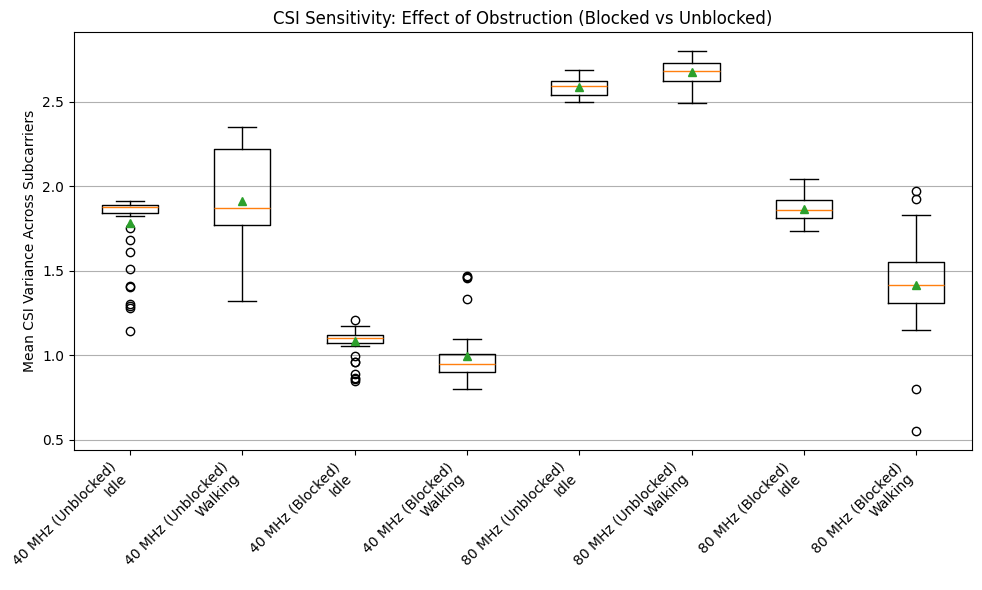

Condition,Motion,Static,Delta (Motion-Static)
Scenario,,,
40 MHz (Blocked),0.993156,1.080951,-0.087795
40 MHz (Unblocked),1.915415,1.783172,0.132243
80 MHz (Blocked),1.417466,1.867565,-0.450099
80 MHz (Unblocked),2.676836,2.588158,0.088679


In [97]:
plt.figure(figsize=(10, 6))

labels = []
data = []

scenario_order = [
    "40 MHz (Unblocked)", "40 MHz (Blocked)",
    "80 MHz (Unblocked)", "80 MHz (Blocked)"
]

for scenario in scenario_order:
    for condition in ["Idle", "Walking"]:
        vals = blocked_df[
            (blocked_df["Scenario"] == scenario) &
            (blocked_df["Condition"] == condition)
        ]["CSI Variance"].values

        data.append(vals)
        labels.append(f"{scenario}\n{condition}")

plt.boxplot(data, tick_labels=labels, showmeans=True)

plt.ylabel("Mean CSI Variance Across Subcarriers")
plt.title("CSI Sensitivity: Effect of Obstruction (Blocked vs Unblocked)")
plt.grid(True, axis="y")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

blocked_summary = (
    blocked_df
    .groupby(["Scenario", "Condition"])["CSI Variance"]
    .mean()
    .unstack()
)

# Rename for consistency
blocked_summary = blocked_summary.rename(columns={
    "Idle": "Static",
    "Walking": "Motion"
})

# Compute delta
blocked_summary["Delta (Motion-Static)"] = (
    blocked_summary["Motion"] - blocked_summary["Static"]
)

# Reorder columns
blocked_summary = blocked_summary[["Motion", "Static", "Delta (Motion-Static)"]]

display(blocked_summary)